<a href="https://colab.research.google.com/github/princepatel2004/Edunet-Summer-Intership-/blob/main/%5BDay_6%5D_11_07_2026_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 11-07-2026 Linear Regression Model

# Import Libraries and Dataset

In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [15]:
df = pd.read_csv("/green_energy_regression.csv")
df.head()

,State,Region,Population_Million,GSDP_Billion,Solar_Capacity_MW,Wind_Capacity_MW,Hydro_Capacity_MW,Biomass_Capacity_MW,Renewable_Investment_Crore,Energy_Demand_GWh,Renewable_Percentage,Annual_CO2_Reduction_Tons
0,Chhattisgarh,Central,17.80,808.79,1821.39,846.45,692.53,295.41,2409.84,5726.58,68.43,2145.78
1,Punjab,North,63.12,1198.13,3215.07,1917.31,276.35,315.17,3349.19,23623.50,80.00,3935.86
2,Karnataka,South,53.60,1515.87,4360.70,1522.84,403.94,211.54,4337.29,14072.65,80.00,4493.37
3,West Bengal,East,66.67,3600.53,11650.87,9042.96,594.82,437.77,12652.76,21238.70,80.00,14604.56
4,Punjab,North,93.90,5113.16,29011.39,13584.47,462.73,425.35,27719.83,20567.57,80.00,31662.28


# Information about Dataset

In [16]:
print("Rows and Columns :", df.shape)
df.columns
df.info()

Rows and Columns : (120, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   State                       120 non-null    object 
 1   Region                      112 non-null    object 
 2   Population_Million          120 non-null    float64
 3   GSDP_Billion                112 non-null    float64
 4   Solar_Capacity_MW           112 non-null    float64
 5   Wind_Capacity_MW            112 non-null    float64
 6   Hydro_Capacity_MW           120 non-null    float64
 7   Biomass_Capacity_MW         120 non-null    float64
 8   Renewable_Investment_Crore  112 non-null    float64
 9   Energy_Demand_GWh           120 non-null    float64
 10  Renewable_Percentage        120 non-null    float64
 11  Annual_CO2_Reduction_Tons   120 non-null    float64
dtypes: float64(10), object(2)
memory usage: 11.4+ KB


## Feature Description

• State – Name of the Indian state.

• Region – Geographical region of the state.

• Population_Million – Population of the state (in millions).

• GSDP_Billion – Gross State Domestic Product (in billion).

• Solar_Capacity_MW – Installed solar power capacity.

• Wind_Capacity_MW – Installed wind power capacity.

• Hydro_Capacity_MW – Installed hydro power capacity.

• Biomass_Capacity_MW – Installed biomass power capacity.

• Renewable_Investment_Crore – Investment in renewable energy.

• Energy_Demand_GWh – Annual electricity demand.

• Renewable_Percentage – Percentage of energy generated from renewable sources.

• Annual_CO2_Reduction_Tons – Annual CO₂ reduction achieved due to renewable
energy (Target Variable).

# General Observations

• The dataset contains both categorical and numerical features.

• Renewable energy capacities vary significantly across different states.

• Higher renewable investment generally results in higher renewable energy capacity.

• States with higher GSDP tend to invest more in renewable energy.

• Energy demand generally increases with population.

• The target variable is continuous, making this a regression problem.

# Check and Handle Missing Values

In [17]:
df.isnull().sum()

,0
State,0
Region,8
Population_Million,0
GSDP_Billion,8
Solar_Capacity_MW,8
Wind_Capacity_MW,8
Hydro_Capacity_MW,0
Biomass_Capacity_MW,0
Renewable_Investment_Crore,8
Energy_Demand_GWh,0


# Missing Value Analysis

The dataset contains missing values in some numerical and categorical columns.

Numerical missing values will be replaced using the mean because the mean preserves the average value of the data.

Categorical missing values will be replaced using the mode because it represents the most frequently occurring category.

In [19]:
numerical_columns = [
    "GSDP_Billion",
    "Solar_Capacity_MW",
    "Wind_Capacity_MW",
    "Renewable_Investment_Crore"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

In [21]:
df.fillna({"Region": df["Region"].mode()[0]}, inplace=True)

df.isnull().sum()

,0
State,0
Region,0
Population_Million,0
GSDP_Billion,0
Solar_Capacity_MW,0
Wind_Capacity_MW,0
Hydro_Capacity_MW,0
Biomass_Capacity_MW,0
Renewable_Investment_Crore,0
Energy_Demand_GWh,0


# Why Mean and Mode?

• Mean is suitable for numerical features because it maintains the average of the data.

• Mode is suitable for categorical features because it replaces missing values with the most common category.

These methods are simple, effective, and preserve the dataset size.

# Feature Engineering

A new feature called Total_Renewable_Capacity is created.

It represents the total installed renewable energy capacity from Solar, Wind, Hydro, and Biomass.

In [22]:
df["Total_Renewable_Capacity"] = (
    df["Solar_Capacity_MW"] +
    df["Wind_Capacity_MW"] +
    df["Hydro_Capacity_MW"] +
    df["Biomass_Capacity_MW"]
)
df.head()

,State,Region,Population_Million,GSDP_Billion,Solar_Capacity_MW,Wind_Capacity_MW,Hydro_Capacity_MW,Biomass_Capacity_MW,Renewable_Investment_Crore,Energy_Demand_GWh,Renewable_Percentage,Annual_CO2_Reduction_Tons,Total_Renewable_Capacity
0,Chhattisgarh,Central,17.80,808.79,1821.39,846.45,692.53,295.41,2409.84,5726.58,68.43,2145.78,3655.78
1,Punjab,North,63.12,1198.13,3215.07,1917.31,276.35,315.17,3349.19,23623.50,80.00,3935.86,5723.90
2,Karnataka,South,53.60,1515.87,4360.70,1522.84,403.94,211.54,4337.29,14072.65,80.00,4493.37,6499.02
3,West Bengal,East,66.67,3600.53,11650.87,9042.96,594.82,437.77,12652.76,21238.70,80.00,14604.56,21726.42
4,Punjab,North,93.90,5113.16,29011.39,13584.47,462.73,425.35,27719.83,20567.57,80.00,31662.28,43483.94


# Relationship Between Features

• Population influences energy demand.

• Renewable investment influences solar and wind capacity.

• Solar, Wind, Hydro, and Biomass capacities collectively increase renewable percentage.

• Higher renewable percentage leads to greater CO₂ reduction.

# Seaborn Visualizations

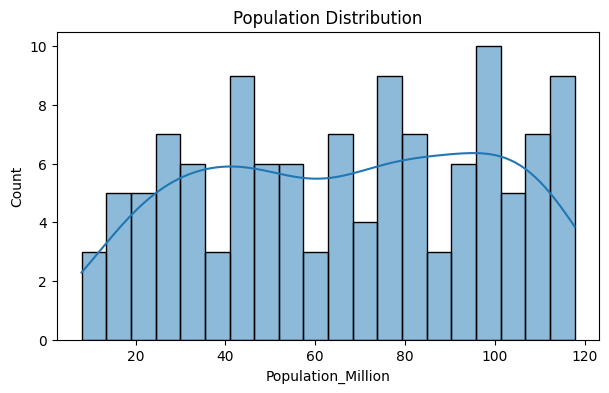

In [23]:
# Histogram of Population
plt.figure(figsize=(7,4))
sns.histplot(df["Population_Million"], bins=20, kde=True)
plt.title("Population Distribution")
plt.show()

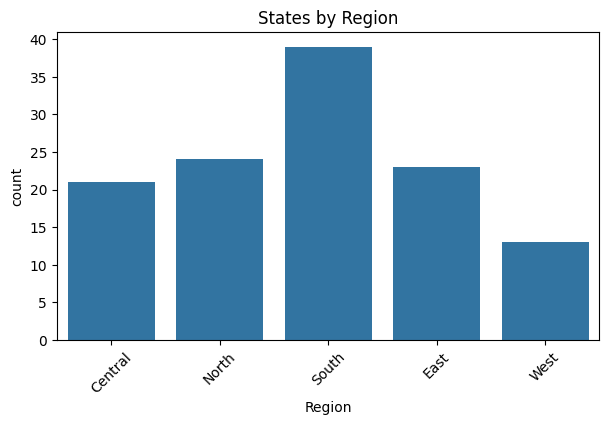

In [24]:
#Countplot of Region
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Region")
plt.title("States by Region")
plt.xticks(rotation=45)
plt.show()

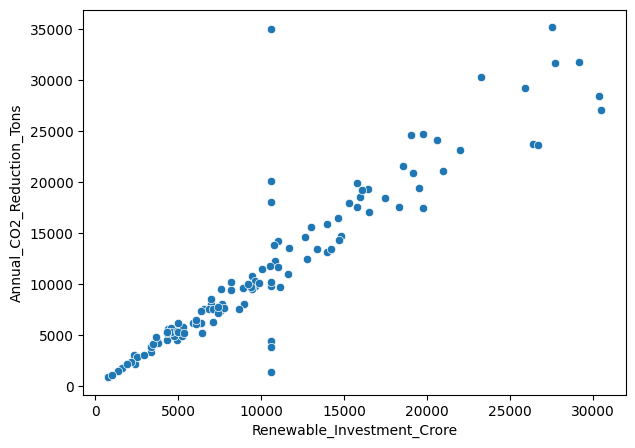

In [25]:
# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Renewable_Investment_Crore",
    y="Annual_CO2_Reduction_Tons"
)

plt.show()

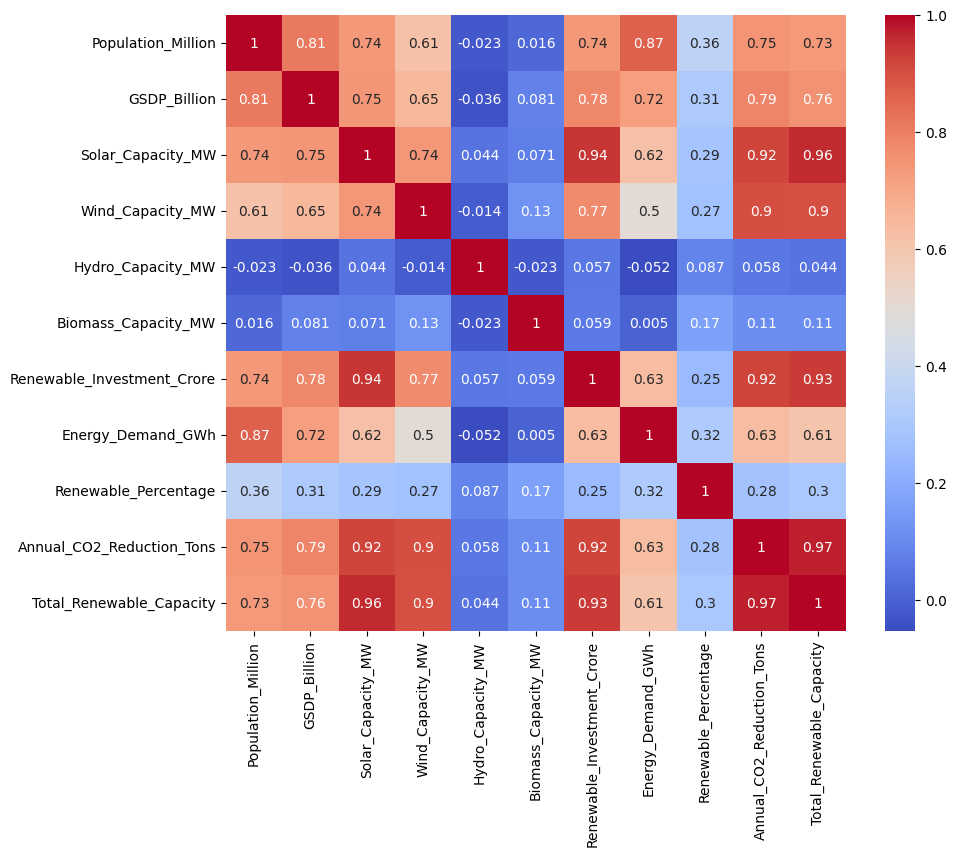

In [26]:
# Corelational Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Encoding Categorical Variables

Linear Regression cannot directly work with text values like State and Region.

We'll convert them into numerical columns.

In [27]:
df = pd.get_dummies(
    df,
    columns=["State", "Region"],
    drop_first=True
)
df.head()

,Population_Million,GSDP_Billion,Solar_Capacity_MW,Wind_Capacity_MW,Hydro_Capacity_MW,Biomass_Capacity_MW,Renewable_Investment_Crore,Energy_Demand_GWh,Renewable_Percentage,Annual_CO2_Reduction_Tons,...,State_Odisha,State_Punjab,State_Rajasthan,State_Tamil Nadu,State_Uttar Pradesh,State_West Bengal,Region_East,Region_North,Region_South,Region_West
0,17.80,808.79,1821.39,846.45,692.53,295.41,2409.84,5726.58,68.43,2145.78,...,False,False,False,False,False,False,False,False,False,False
1,63.12,1198.13,3215.07,1917.31,276.35,315.17,3349.19,23623.50,80.00,3935.86,...,False,True,False,False,False,False,False,True,False,False
2,53.60,1515.87,4360.70,1522.84,403.94,211.54,4337.29,14072.65,80.00,4493.37,...,False,False,False,False,False,False,False,False,True,False
3,66.67,3600.53,11650.87,9042.96,594.82,437.77,12652.76,21238.70,80.00,14604.56,...,False,False,False,False,False,True,True,False,False,False
4,93.90,5113.16,29011.39,13584.47,462.73,425.35,27719.83,20567.57,80.00,31662.28,...,False,True,False,False,False,False,False,True,False,False


# Scaling Numerical Features

The numerical features have different ranges.

Scaling transforms all numerical features to a similar scale.

StandardScaler standardizes the data with mean = 0 and standard deviation = 1.

This improves numerical stability and model performance.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
target = "Annual_CO2_Reduction_Tons"

numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_cols.remove(target)

df.head()

,Population_Million,GSDP_Billion,Solar_Capacity_MW,Wind_Capacity_MW,Hydro_Capacity_MW,Biomass_Capacity_MW,Renewable_Investment_Crore,Energy_Demand_GWh,Renewable_Percentage,Annual_CO2_Reduction_Tons,...,State_Odisha,State_Punjab,State_Rajasthan,State_Tamil Nadu,State_Uttar Pradesh,State_West Bengal,Region_East,Region_North,Region_South,Region_West
0,17.80,808.79,1821.39,846.45,692.53,295.41,2409.84,5726.58,68.43,2145.78,...,False,False,False,False,False,False,False,False,False,False
1,63.12,1198.13,3215.07,1917.31,276.35,315.17,3349.19,23623.50,80.00,3935.86,...,False,True,False,False,False,False,False,True,False,False
2,53.60,1515.87,4360.70,1522.84,403.94,211.54,4337.29,14072.65,80.00,4493.37,...,False,False,False,False,False,False,False,False,True,False
3,66.67,3600.53,11650.87,9042.96,594.82,437.77,12652.76,21238.70,80.00,14604.56,...,False,False,False,False,False,True,True,False,False,False
4,93.90,5113.16,29011.39,13584.47,462.73,425.35,27719.83,20567.57,80.00,31662.28,...,False,True,False,False,False,False,False,True,False,False


# Train-Test Split

The dataset is divided into training and testing sets.

Training Data (80%):
Used to train the Linear Regression model.

Testing Data (20%):
Used to evaluate the performance of the trained model on unseen data.

The target variable is Annual_CO2_Reduction_Tons.

In [30]:
# Features (Independent Variables)
X = df.drop("Annual_CO2_Reduction_Tons", axis=1)

# Target (Dependent Variable)
y = df["Annual_CO2_Reduction_Tons"]

In [31]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (96, 28)
Testing Data Shape : (24, 28)


# Building the Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values.

The model learns the relationship between the independent variables and the target variable by fitting the best possible straight line.

In [32]:
# create model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

LinearRegression()

# The Linear Regression model has now learned the relationship between renewable energy features and Annual CO₂ Reduction using the training data.

In [33]:
# predict
y_pred = model.predict(X_test)

In [34]:
# compare actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
44,5263.45,4755.336699
47,30334.25,23887.792099
4,31662.28,31725.858151
55,9529.69,8960.065659
26,8009.96,5807.647796
64,17417.89,14712.308712
73,5736.72,6324.331096
10,3338.31,6113.260256
40,4859.13,3049.162955
107,6182.39,6314.301973


The table above compares the actual CO₂ reduction values with the predicted values generated by the Linear Regression model.

Smaller differences between the actual and predicted values indicate better model performance.

# Model Evaluation

The Linear Regression model is evaluated using:

• Mean Absolute Error (MAE)

• Mean Squared Error (MSE)

• Root Mean Squared Error (RMSE)

• R² Score

These metrics measure the prediction accuracy and overall model performance.

In [35]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R² Score :", r2)

Mean Absolute Error : 1527.5640357053928
Mean Squared Error : 4141690.844955118
Root Mean Squared Error : 2035.1144550012705
R² Score : 0.9440895367007021


# Understanding Error Values

1. Mean Absolute Error (MAE)
Measures the average prediction error.

Lower MAE indicates better accuracy.


2. Mean Squared Error (MSE)
Measures the squared difference between actual and predicted values.

Lower MSE indicates fewer large prediction errors.


3. Root Mean Squared Error (RMSE)
Represents the average prediction error in the original unit.

Lower RMSE indicates better model performance.


4. R² Score
Measures how well the model explains the variation in the target variable.

R² = 1.0 → Perfect prediction

R² > 0.90 → Excellent model

R² between 0.70–0.90 → Good model

R² < 0.50 → Weak model

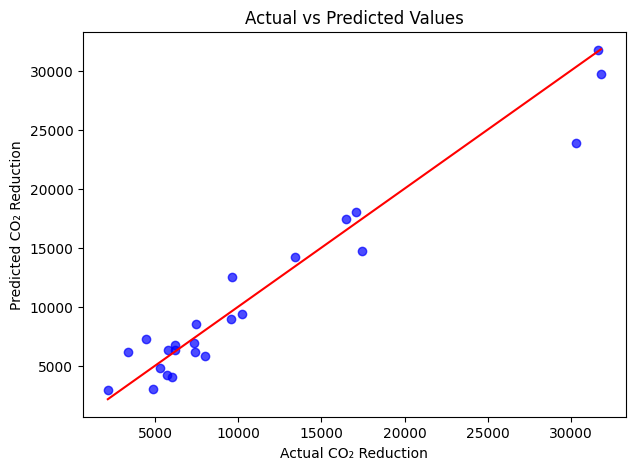

In [42]:
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)

# Ideal reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red')

plt.xlabel("Actual CO₂ Reduction")
plt.ylabel("Predicted CO₂ Reduction")
plt.title("Actual vs Predicted Values")

plt.show()

# Observation

The closer the points lie to an imaginary diagonal line, the better the prediction accuracy of the Linear Regression model.

A scattered pattern indicates larger prediction errors.

# Final Insights

• The dataset shows a positive relationship between renewable investment and CO₂ reduction.

• Higher renewable energy capacity generally results in greater CO₂ reduction.

• Population influences energy demand.

• Feature engineering improved the representation of renewable capacity.

• Missing values were successfully handled using mean and mode imputation.

• StandardScaler standardized numerical features.

• Categorical variables were encoded using pd.get_dummies().

• The Linear Regression model successfully predicted Annual CO₂ Reduction.

• Model evaluation metrics indicate how accurately the model predicts unseen data.

# Conclusion

• In this task, a sustainability dataset was analyzed using Exploratory Data Analysis (EDA) and preprocessing techniques.

• Missing values were handled, feature engineering was performed, numerical features were scaled, and categorical features were encoded.

• A Linear Regression model was trained to predict Annual CO₂ Reduction.

• The model was evaluated using MAE, MSE, RMSE, and R² Score, demonstrating its ability to predict continuous values based on renewable energy indicators.

• This workflow provides a complete machine learning pipeline for solving a regression problem using sustainability data.